In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
import json
import os
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
!unzip final_soap_vectors.zip -d /content/

Archive:  final_soap_vectors.zip
   creating: /content/final_soap_vectors/
  inflating: /content/__MACOSX/._final_soap_vectors  
  inflating: /content/final_soap_vectors/soap_vec_Cu(OH)2.npy  
  inflating: /content/__MACOSX/final_soap_vectors/._soap_vec_Cu(OH)2.npy  
  inflating: /content/final_soap_vectors/soap_vec_BaCO3.npy  
  inflating: /content/__MACOSX/final_soap_vectors/._soap_vec_BaCO3.npy  
  inflating: /content/final_soap_vectors/soap_vec_Na2O2.npy  
  inflating: /content/__MACOSX/final_soap_vectors/._soap_vec_Na2O2.npy  
  inflating: /content/final_soap_vectors/soap_vec_SrCO3.npy  
  inflating: /content/__MACOSX/final_soap_vectors/._soap_vec_SrCO3.npy  
  inflating: /content/final_soap_vectors/soap_vec_Ca.npy  
  inflating: /content/__MACOSX/final_soap_vectors/._soap_vec_Ca.npy  
  inflating: /content/final_soap_vectors/soap_vec_Be.npy  
  inflating: /content/__MACOSX/final_soap_vectors/._soap_vec_Be.npy  
  inflating: /content/final_soap_vectors/soap_vec_TbO1.72.npy  
  inf

In [ ]:
SOAP_DIR = "/content/final_soap_vectors"

with open("/content/final_reaction_data.json", "r") as f:
    reactions = json.load(f)

print("Total reactions:", len(reactions))

Total reactions: 292


In [ ]:
X = []
y = []

used = 0
skipped = 0

for rxn in reactions:
    vec = None
    missing = False
    missing_compounds = []

    # ---- REACTANTS ----
    for r in rxn["reactants"]:
        path = f"{SOAP_DIR}/soap_vec_{r['formula']}.npy"

        if not os.path.exists(path):
            missing = True
            missing_compounds.append(r["formula"])
            break

        v = np.load(path)

        if vec is None:
            vec = np.zeros_like(v)

        vec -= r["coeff"] * v

    # ---- PRODUCTS ----
    if not missing:
        for p in rxn["products"]:
            path = f"{SOAP_DIR}/soap_vec_{p['formula']}.npy"

            if not os.path.exists(path):
                missing = True
                missing_compounds.append(p["formula"])
                break

            v = np.load(path)
            vec += p["coeff"] * v

    # ---- HANDLE SKIP ----
    if missing:
        print(f"❌ Skipped Reaction {rxn['no']} → Missing: {set(missing_compounds)}")
        skipped += 1
        continue

    # ---- VALID ----
    X.append(vec)
    y.append(rxn["delta_H_kJ_mol"])
    used += 1

# ---- FINAL ----
X = np.array(X)
y = np.array(y)

print("\n✅ SUMMARY")
print("Used reactions:", used)
print("Skipped reactions:", skipped)
print("Dataset shape:", X.shape)


✅ SUMMARY
Used reactions: 292
Skipped reactions: 0
Dataset shape: (292, 252)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

model.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=0)

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 239.66971232938863
R²: 0.6457696874095108


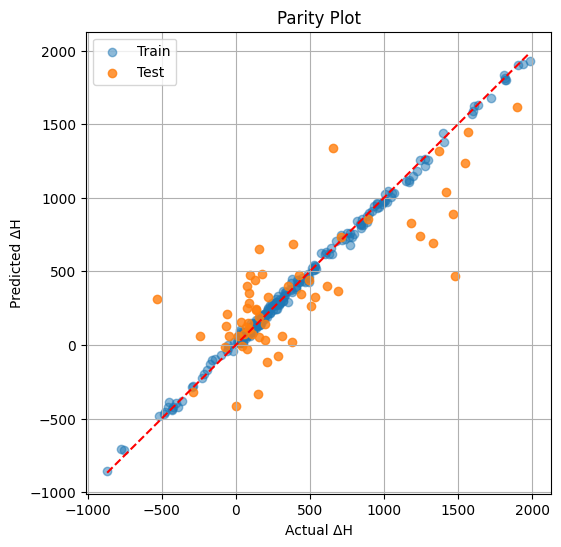

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_train, model.predict(X_train), alpha=0.5, label="Train")
plt.scatter(y_test, y_pred, alpha=0.8, label="Test")

min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual ΔH")
plt.ylabel("Predicted ΔH")
plt.title("Parity Plot")

plt.legend()
plt.grid(True)
plt.show()

Text chunk for the previous codes

In [ ]:
!pip install mp-api pymatgen -q
!pip install ase dscribe -q
!pip install catboost -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━

In [ ]:
from pymatgen.ext.matproj import MPRester
from mp_api.client import MPRester
from pymatgen.io.ase import AseAtomsAdaptor

from ase.io import read
from ase.build import molecule
from ase import Atoms

from dscribe.descriptors import SOAP

import numpy as np
import os
import json
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

Removing outliers based on enthalpy (delta_H_kJ_mol) using IQR method

In [ ]:
# Remove outliers based on enthalpy using IQR
with open('/content/dataset.json', 'r') as f:
    data = json.load(f)

# Get enthalpy values
enthalpies = [rxn["delta_H_kJ_mol"] for rxn in data if "delta_H_kJ_mol" in rxn]
enthalpies = np.array(enthalpies)

# Calculate IQR
Q1 = np.percentile(enthalpies, 25)
Q3 = np.percentile(enthalpies, 75)
IQR = Q3 - Q1

# Set bounds for filtering
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Filter reactions within bounds
filtered_data = [rxn for rxn in data if "delta_H_kJ_mol" in rxn and lower_bound <= rxn["delta_H_kJ_mol"] <= upper_bound]

print(f"Original reactions: {len(data)}")
print(f"Filtered reactions: {len(filtered_data)}")

# Save filtered data
with open('filtered_dataset.json', 'w') as f:
    json.dump(filtered_data, f, indent=4)

Lower bound: -1076.6193749999998
Upper bound: 1993.807625
Original reactions: 360
Filtered reactions: 332


Extracting the products and reactants formulas differently in a file

In [ ]:
# Load dataset
with open('filtered_dataset.json', 'r') as f:
    data = json.load(f)

reactant_formulas = []
product_formulas = []

# Loop through reactions
for rxn in data:
    for r in rxn.get("reactants", []):
        reactant_formulas.append(r["formula"])
    for p in rxn.get("products", []):
        product_formulas.append(p["formula"])

# Save to file
with open('reactant_formulas.json', 'w') as f:
    json.dump(reactant_formulas, f, indent=4)
with open('product_formulas.json', 'w') as f:
    json.dump(product_formulas, f, indent=4)

print("Saved all reactant formulas!")

Saved all reactant formulas!


API key to access the matrials project

In [ ]:
API_KEY = "dJuAIwau1YJKO6All1s55QmI2lg9i26n"

Extracting the material id form the materials project for the element with 0(or minimum) null energy

In [ ]:
# Load reactant and product formulas
with open('/content/reactant_formulas.json', 'r') as f:
    reactants = set(json.load(f))
with open('/content/product_formulas.json', 'r') as f:
    products = set(json.load(f))

# Combine unique formulas
all_formulas = reactants.union(products)

results = []
seen = set()  # track processed formulas

# Get material_id for each formula
with MPRester(API_KEY) as mpr:
    for formula in all_formulas:
        if formula in seen:
            continue
        seen.add(formula)

        try:
            res = mpr.summary.search(formula=formula)
            material_id = res[0]["material_id"] if res else None
        except:
            material_id = None

        results.append({"formula": formula, "material_id": material_id})

# Save results
with open('/content/formula_material_map.json', 'w') as f:
    json.dump(results, f, indent=4)

print("Saved as formula_material_map.json")

/tmp/ipykernel_3099/2458278100.py:21: DeprecationWarning: Accessing summary data through MPRester.summary is deprecated. Please use MPRester.materials.summary instead.
  res = mpr.summary.search(formula=formula)


Retrieving SummaryDoc documents:   0%|          | 0/4 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/5 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/5 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/4 [00:00<?, ?it/s]

...

Retrieving SummaryDoc documents:   0%|          | 0/11 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/7 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/10 [00:00<?, ?it/s]

Saved as formula_material_map.json


Checking which compound's material id was not able to be fetched

In [ ]:
# Load your file
with open('formula_material_map.json', 'r') as f:
    data = json.load(f)

unique_data = {}
null_compounds = []

# Process entries
for item in data:
    formula = item["formula"]
    material_id = item["material_id"]

    # Track nulls
    if material_id is None:
        null_compounds.append(formula)

    # Remove duplicates (keep first occurrence)
    if formula not in unique_data:
        unique_data[formula] = material_id

# Convert back to list format
cleaned_data = [
    {"formula": f, "material_id": mid}
    for f, mid in unique_data.items()
]

# Save cleaned file
with open('unique_formula_material_map.json', 'w') as f:
    json.dump(cleaned_data, f, indent=4)

# Print null compounds
print("❌ Compounds with NULL material_id:")
for comp in set(null_compounds):
    print(comp)

print("\n✅ Total unique compounds:", len(cleaned_data))

❌ Compounds with NULL material_id:
MoO
TBO1.72
WO2.72
WO
GeO
RuO3
Tb1.72
PbO_2
SbO
TBO1.81
TcO3
Fe(OH)3
SeO
In2O
U4O9
Tb1.81
WO2.9
WO2.96
AsO
Ga2O

✅ Total unique compounds: 268


Extracting the materials structure form the material id using the materials project only

In [ ]:
# Folder to store structures
SAVE_DIR = "/content/structures"
os.makedirs(SAVE_DIR, exist_ok=True)

# Load material map
with open('/content/formula_material_map.json', 'r') as f:
    data = json.load(f)

# Download structures from Materials Project
with MPRester(API_KEY) as mpr:
    for item in data:
        formula = item["formula"]
        material_id = item["material_id"]
        if material_id is None:
            continue
        try:
            structure = mpr.get_structure_by_material_id(material_id)

            # If multiple structures returned, take the first one
            if isinstance(structure, list):
                if not structure:
                    continue
                structure = structure[0]

            # Save as CIF file
            file_path = os.path.join(SAVE_DIR, f"{formula}.cif")
            structure.to(filename=file_path)
            print(f"Saved: {file_path}")
        except Exception as e:
            print(f"Error for {formula}: {e}")

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/structures/SeO2.cif


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/structures/Be(OH)2.cif


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saved: /content/structures/Pb2CO4.cif


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/structures/NaO2.cif


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/structures/KO2.cif


Passing the structure to SOAP to get a soap vector based on the structures

In [ ]:
# Paths for input structures and output SOAP vectors
STRUCT_DIR = "/content/structures"
SAVE_DIR = "/content/soap_from_structures"
os.makedirs(SAVE_DIR, exist_ok=True)

# Process each CIF file
for file in os.listdir(STRUCT_DIR):
    if file.endswith(".cif"):
        path = os.path.join(STRUCT_DIR, file)
        try:
            # Read structure as ASE atoms
            atoms = read(path)

            # Define SOAP descriptor
            soap = SOAP(
                species=list(set(atoms.get_chemical_symbols())),
                compression={'mode': 'mu2', 'species_weighting': None},
                periodic=True,
                r_cut=5.0,
                n_max=8,
                l_max=6
            )

            # Compute SOAP vector
            soap_vec = soap.create(atoms).mean(axis=0)

            # Save vector
            formula = file.replace(".cif", "")
            save_path = os.path.join(SAVE_DIR, f"soap_vec_{formula}.npy")
            np.save(save_path, soap_vec)

            print(f"{formula} | Shape: {soap_vec.shape}")
        except Exception as e:
            print(f"Error: {file}")

PtO2 | Shape: (252,)
Sc2O3 | Shape: (252,)
Al | Shape: (252,)
CO2 | Shape: (252,)
Ag | Shape: (252,)
Al2O3 | Shape: (252,)
PbCO3 | Shape: (252,)
KO | Shape: (252,)
UO2 | Shape: (252,)
Ti | Shape: (252,)
Ba(OH)2 | Shape: (252,)
PrO2 | Shape: (252,)
Er2O3 | Shape: (252,)
Na2O2 | Shape: (252,)
Na | Shape: (252,)
Tl | Shape: (252,)
Pu | Shape: (252,)
Li2CO3 | Shape: (252,)
NbO | Shape: (252,)
ThO2 | Shape: (252,)
Eu | Shape: (252,)
NA2O | Shape: (252,)
MgCO3 | Shape: (252,)
PuO2 | Shape: (252,)
Cs2CO3 | Shape: (252,)
Sr(OH)2 | Shape: (252,)
ThO | Shape: (252,)
NpO2 | Shape: (252,)
U3O8 | Shape: (252,)
ZnCO3 | Shape: (252,)
Nb2O5 | Shape: (252,)
La2O3 | Shape: (252,)
Pr | Shape: (252,)
Ag2O | Shape: (252,)
V2O3 | Shape: (252,)
HfO2 | Shape: (252,)
Al2O | Shape: (252,)
Lu | Shape: (252,)
VO2 | Shape: (252,)
W | Shape: (252,)
Ge | Shape: (252,)
Au2O3 | Shape: (252,)
NbO2 | Shape: (252,)
CsO | Shape: (252,)
UO3 | Shape: (252,)
Au | Shape: (252,)
CoO | Shape: (252,)
Rb2O | Shape: (252,)
NaO | S

Manually creating SOAP vectors for WO3 and TbO2

In [ ]:
SAVE_DIR = '/content/soap_from_structures'

# Target material details
target_formula = "WO3"
target_material_id = "mp-2383161"

try:
    with MPRester(API_KEY) as mpr:
        print(f"Fetching structure for {target_formula} ({target_material_id})...")

        # Get structure from Materials Project
        structure = mpr.get_structure_by_material_id(target_material_id)
        if isinstance(structure, list):
            structure = structure[0]

        # Convert to ASE atoms
        atoms = AseAtomsAdaptor.get_atoms(structure)

        # Define SOAP descriptor
        soap = SOAP(
            species=list(set(atoms.get_chemical_symbols())),
            compression={'mode': 'mu2', 'species_weighting': None},
            periodic=True,
            r_cut=5.0,
            n_max=8,
            l_max=6
        )

        # Compute SOAP vector
        print("Computing SOAP vector...")
        soap_vec = soap.create(atoms).mean(axis=0)

        # Save result
        filename = os.path.join(SAVE_DIR, f"soap_vec_{target_formula}.npy")
        np.save(filename, soap_vec)

        print(f"Successfully saved {filename}")
        print(f"Vector shape: {soap_vec.shape}")

except Exception as e:
    print(f"Error processing {target_formula}: {e}")

Fetching structure for WO3 (mp-2383161)...


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Computing SOAP vector...
Successfully saved /content/soap_from_structures/soap_vec_WO3.npy
Vector shape: (252,)


In [ ]:
SAVE_DIR = '/content/soap_from_structures'

# Target material
target_formula = "TbO2"
target_material_id = "mp-2458"

try:
    with MPRester(API_KEY) as mpr:
        print(f"Fetching structure for {target_formula} ({target_material_id})...")

        # Get structure
        structure = mpr.get_structure_by_material_id(target_material_id)
        if isinstance(structure, list):
            structure = structure[0]

        # Convert to ASE atoms
        atoms = AseAtomsAdaptor.get_atoms(structure)

        # Define SOAP descriptor
        soap = SOAP(
            species=list(set(atoms.get_chemical_symbols())),
            compression={'mode': 'mu2', 'species_weighting': None},
            periodic=True,
            r_cut=5.0,
            n_max=8,
            l_max=6
        )

        # Compute SOAP vector
        print("Computing SOAP vector...")
        soap_vec = soap.create(atoms).mean(axis=0)

        # Save result
        filename = os.path.join(SAVE_DIR, f"soap_vec_{target_formula}.npy")
        np.save(filename, soap_vec)

        print(f"Successfully saved {filename}")
        print(f"Vector shape: {soap_vec.shape}")

except Exception as e:
    print(f"Error processing {target_formula}: {e}")

Fetching structure for TbO2 (mp-2458)...


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Computing SOAP vector...
Successfully saved /content/soap_from_structures/soap_vec_TbO2.npy
Vector shape: (252,)


For the compounds that had ratios in them we took the soap vectors for them and added them in the same ratio

In [ ]:
WORK_DIR = '/content/soap_from_structures'

# Map the target compounds to their fractional components based on your notes
fractional_compounds = [
    {
        "target": "WO2.96",
        "components": [("WO3", 0.96), ("WO2", 0.04)]
    },
    {
        "target": "WO2.72",
        "components": [("WO3", 0.72), ("WO2", 0.28)]
    },
    {
        "target": "WO2.9",
        "components": [("WO3", 0.90), ("WO2", 0.10)]
    },
    {
        "target": "TbO1.72",
        "components": [("TbO2", 0.4399), ("Tb2O3", 0.28)]
    },
    {
        "target": "TbO1.81",
        "components": [("TbO2", 0.6199), ("Tb2O3", 0.19)]
    }
]

print("Starting algebraic summation for fractional compounds...\n")

for item in fractional_compounds:
    target_formula = item["target"]

    # Initialize the resultant vector as None
    result_vector = None
    success = True

    for base_formula, weight in item["components"]:
        file_path = os.path.join(WORK_DIR, f"soap_vec_{base_formula}.npy")

        try:
            # Load the pre-calculated base vector
            base_vec = np.load(file_path)

            # If this is the first component, initialize an array of zeros of the same shape
            if result_vector is None:
                result_vector = np.zeros_like(base_vec, dtype=np.float64)

            # Perform the algebraic addition
            result_vector += weight * base_vec

        except FileNotFoundError:
            print(f"❌ Error: Cannot create {target_formula}. Missing base vector: {file_path}")
            success = False
            break # Stop trying to build this compound if a piece is missing

    if success:
        # Save the new fractional vector
        save_path = os.path.join(WORK_DIR, f"soap_vec_{target_formula}.npy")
        np.save(save_path, result_vector)
        print(f"✅ Successfully created and saved: {save_path} | Shape: {result_vector.shape}")

print("\n--- Process Complete ---")

Starting algebraic summation for fractional compounds...

✅ Successfully created and saved: /content/soap_from_structures/soap_vec_WO2.96.npy | Shape: (252,)
✅ Successfully created and saved: /content/soap_from_structures/soap_vec_WO2.72.npy | Shape: (252,)
✅ Successfully created and saved: /content/soap_from_structures/soap_vec_WO2.9.npy | Shape: (252,)
✅ Successfully created and saved: /content/soap_from_structures/soap_vec_TbO1.72.npy | Shape: (252,)
✅ Successfully created and saved: /content/soap_from_structures/soap_vec_TbO1.81.npy | Shape: (252,)

--- Process Complete ---


For the elemental compound we used the molecule library to get there structure

In [ ]:
SAVE_DIR = '/content/soap_from_structures'

# List of non-crystalline targets
target_species = ['O2', 'CO2', 'H2O', 'Hg', 'Ga', 'Cs']

print("Generating SOAP vectors for isolated molecules/atoms...\n")

for target in target_species:
    try:
        # Build molecule if available, else fallback to single atom
        try:
            atoms = molecule(target)
        except KeyError:
            atoms = Atoms(target)

        print(f"Built structure for {target} with {len(atoms)} atom(s).")

        # Define SOAP (non-periodic for isolated systems)
        soap = SOAP(
            species=list(set(atoms.get_chemical_symbols())),
            compression={'mode': 'mu2', 'species_weighting': None},
            periodic=False,
            r_cut=5.0,
            n_max=8,
            l_max=6
        )

        # Compute average SOAP vector
        soap_vec = soap.create(atoms).mean(axis=0)

        # Save result
        filename = os.path.join(SAVE_DIR, f"soap_vec_{target}.npy")
        np.save(filename, soap_vec)

        print(f"Saved {filename} | Shape: {soap_vec.shape}\n")

    except Exception as e:
        print(f"Error processing {target}: {e}\n")

print("Process complete")

Generating SOAP vectors for isolated molecules/atoms...

Built structure for O2 with 2 atom(s).
Saved /content/soap_from_structures/soap_vec_O2.npy | Shape: (252,)

Built structure for CO2 with 3 atom(s).
Saved /content/soap_from_structures/soap_vec_CO2.npy | Shape: (252,)

Built structure for H2O with 3 atom(s).
Saved /content/soap_from_structures/soap_vec_H2O.npy | Shape: (252,)

Built structure for Hg with 1 atom(s).
Saved /content/soap_from_structures/soap_vec_Hg.npy | Shape: (252,)

Built structure for Ga with 1 atom(s).
Saved /content/soap_from_structures/soap_vec_Ga.npy | Shape: (252,)

Built structure for Cs with 1 atom(s).
Saved /content/soap_from_structures/soap_vec_Cs.npy | Shape: (252,)

Process complete


In [ ]:
# Directory containing SOAP vectors
SOAP_DIR = "/content/soap_from_structures"

# Load filtered reactions
with open('/content/filtered_dataset.json', 'r') as f:
    reactions = json.load(f)

available = set(os.listdir(SOAP_DIR))

# Check if SOAP vector exists for a formula
def has_soap(formula):
    return f"soap_vec_{formula}.npy" in available

# Keep only reactions where all reactants and products have SOAP vectors
clean_reactions = []
for rxn in reactions:
    valid = True
    for r in rxn.get("reactants", []):
        if not has_soap(r["formula"]):
            valid = False
            break
    if not valid:
        continue
    for p in rxn.get("products", []):
        if not has_soap(p["formula"]):
            valid = False
            break
    if valid:
        clean_reactions.append(rxn)

# Save cleaned reactions
with open('/content/clean_reactions.json', 'w') as f:
    json.dump(clean_reactions, f, indent=4)

print("Clean reactions:", len(clean_reactions))